# Explore here

In [70]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/workspaces/machine-learning-python-template/data/raw/AB_NYC_2019.csv')

In [71]:
#obtener tipo de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [72]:
#dimensiones del dataset
df.shape

(48895, 16)

In [73]:
#resumen estadístico 
display(df.describe())

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [74]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Exploracion y Limpieza de Datos ###

In [75]:
#duplicados por id
print("Duplicados por id:", df["id"].duplicated().sum())
print("Duplicados de fila completa:", df.duplicated().sum())

Duplicados por id: 0
Duplicados de fila completa: 0


In [76]:
#eliminando columnas irrelevantes para predecir el precio

df = df.drop(["id", "name", "host_id", "host_name", "last_review"], axis = 1)

df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [77]:
#revisando valores nulos
print(df.isnull().sum())

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [78]:
#reviews_per_month  nulo cuando el alojamiento nunca recibio reseñas

print(df[df["reviews_per_month"].isnull()]["number_of_reviews"].value_counts())

number_of_reviews
0    10052
Name: count, dtype: int64


In [79]:
#columnas por tipo
print("Categoricas:", list(df.select_dtypes(include = "object").columns))
print("Numericas:", list(df.select_dtypes(include = np.number).columns))

Categoricas: ['neighbourhood_group', 'neighbourhood', 'room_type']
Numericas: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


/tmp/ipykernel_1674/53343227.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categoricas:", list(df.select_dtypes(include = "object").columns))


### Analisis de Variables Univariante ###

analisis de cada variable por separado, como se distribuyen y que valores toman


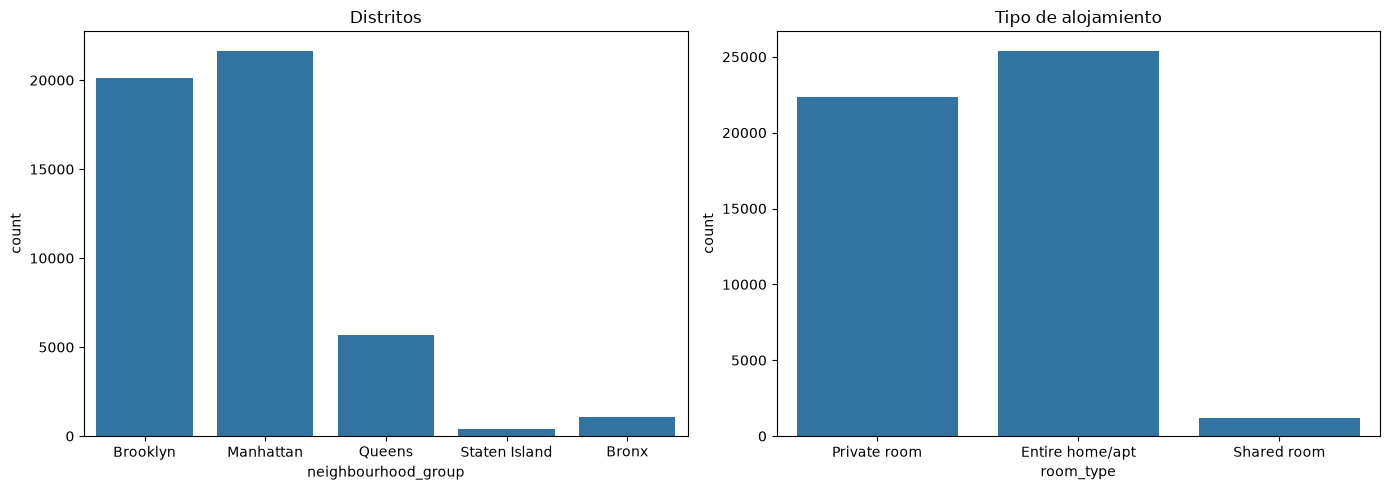

In [80]:
#variables categoricas
fig, axis = plt.subplots(1, 2, figsize = (14, 5))

sns.countplot(ax = axis[0], data = df, x = "neighbourhood_group")
axis[0].set_title("Distritos")

sns.countplot(ax = axis[1], data = df, x = "room_type")
axis[1].set_title("Tipo de alojamiento")

plt.tight_layout()
plt.show()

In [81]:
print(df["neighbourhood_group"].value_counts())
print("")
print(df["room_type"].value_counts())
print("")
print("Barrios distintos:", df["neighbourhood"].nunique())

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Barrios distintos: 221


Manhattan y Brooklyn concentran la gran mayoria de los anuncios.
Casi no hay habitaciones compartidas (`Shared room`), el mercado se reparte entre
apartamentos completos y habitaciones privadas. Hay 221 barrios distintos.

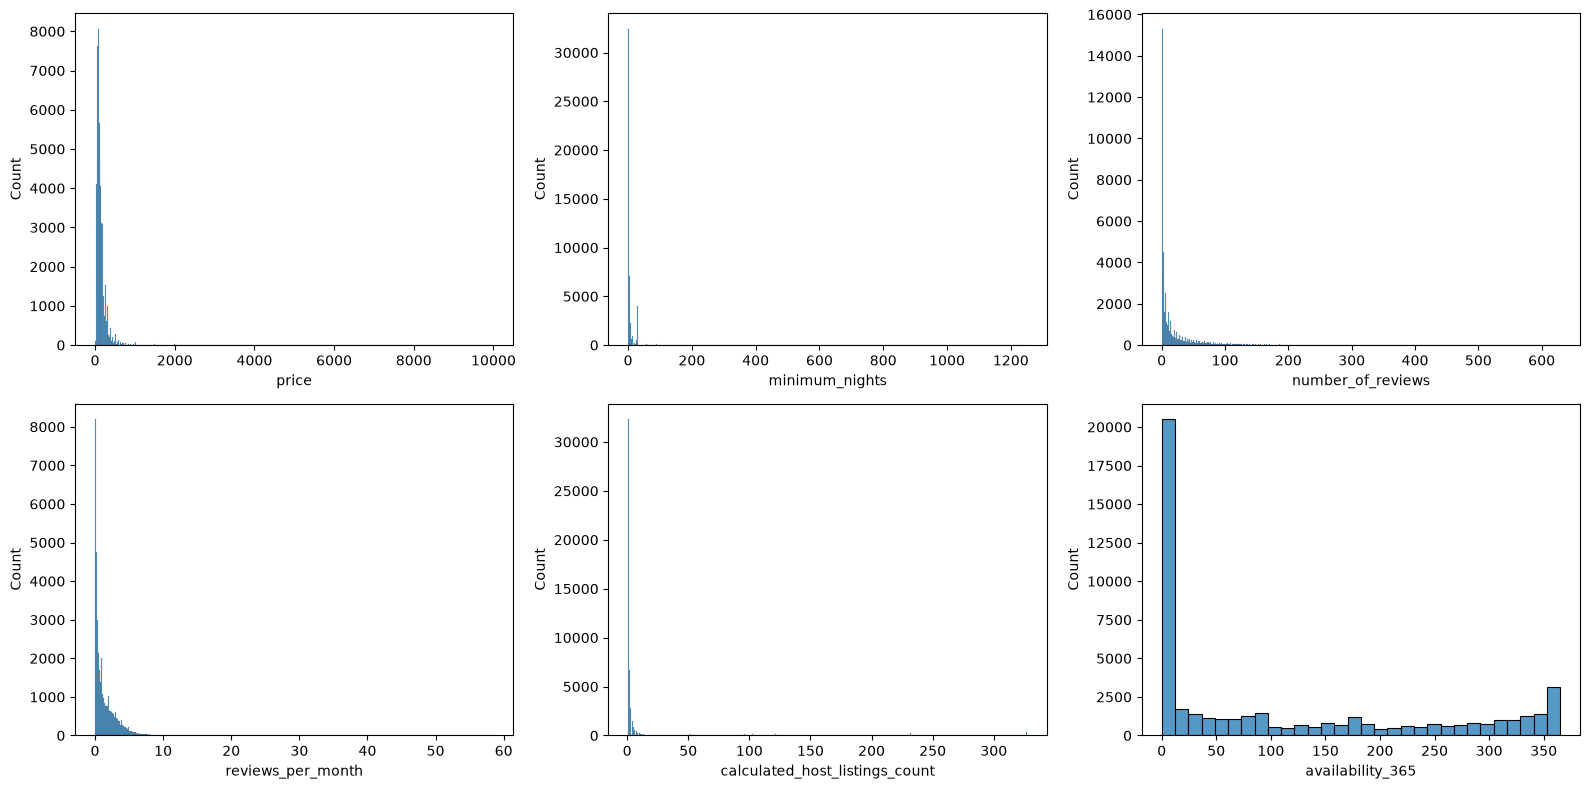

In [82]:
#variables numericas - histogramas
num_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
                      "calculated_host_listings_count", "availability_365"]

fig, axis = plt.subplots(2, 3, figsize = (16, 8))

position = 0
for i in range(2):
    for j in range(3):
        sns.histplot(ax = axis[i, j], data = df, x = num_columns[position])
        position += 1

plt.tight_layout()
plt.show()

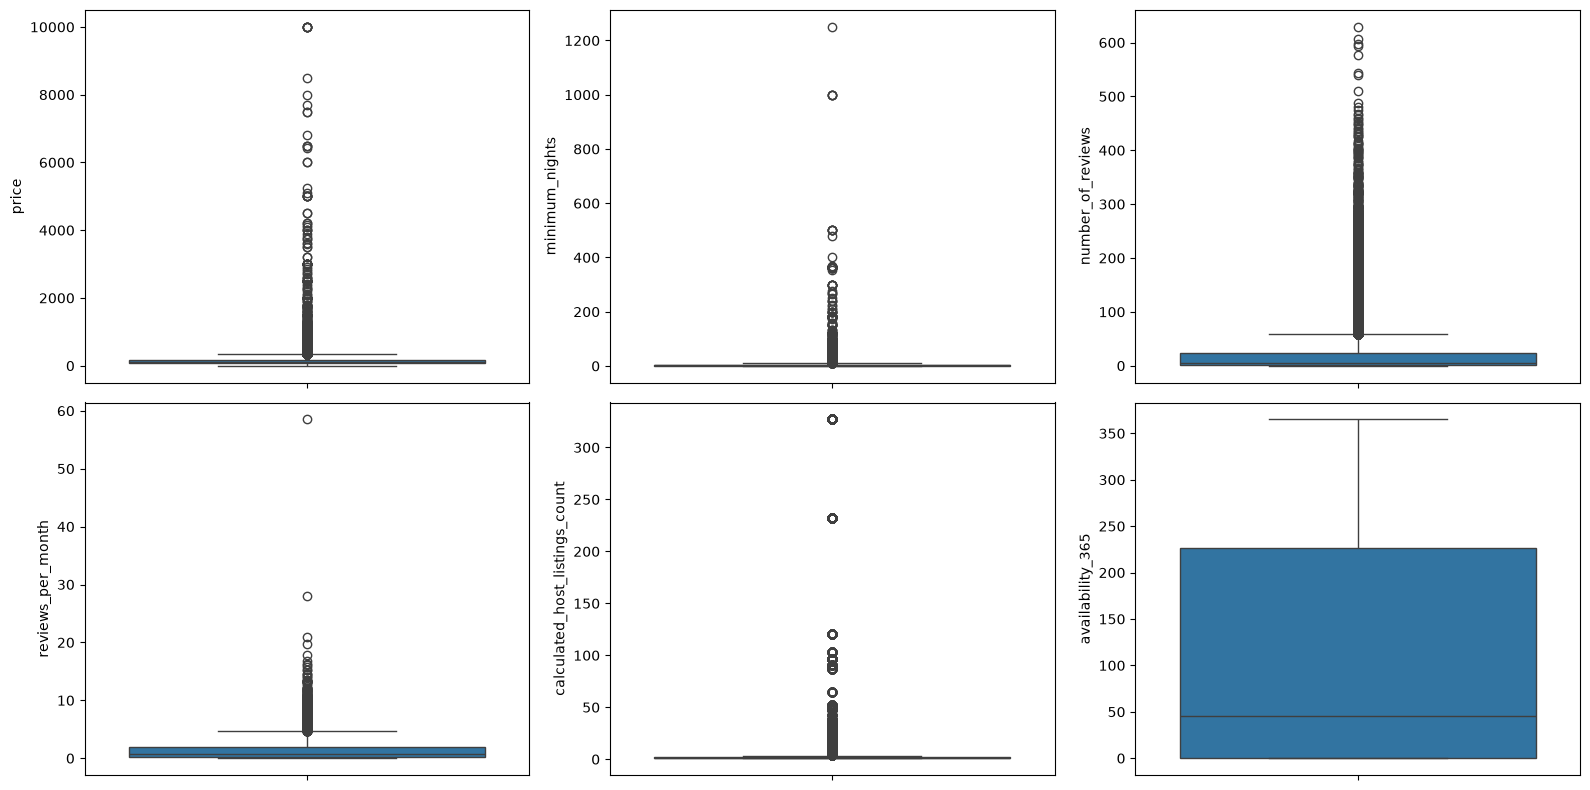

In [83]:
#valores atipicos
fig, axis = plt.subplots(2, 3, figsize = (16, 8))

position = 0
for i in range(2):
    for j in range(3):
        sns.boxplot(ax = axis[i, j], data = df, y = num_columns[position])
        position += 1

plt.tight_layout()
plt.show()

In [84]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


todas las variables numericas estan muy sesgadas a la derecha.
El precio va de 0 a 10.000 dolares y `minimum_nights` llega a 1.250 noches, valores que
claramente son atipicos. Ademas hay alojamientos con precio 0, lo cual no tiene sentido.


### Analisis de Variables Multivariante ###

relacion de las variables entre si, sobre todo con el target (`price`).

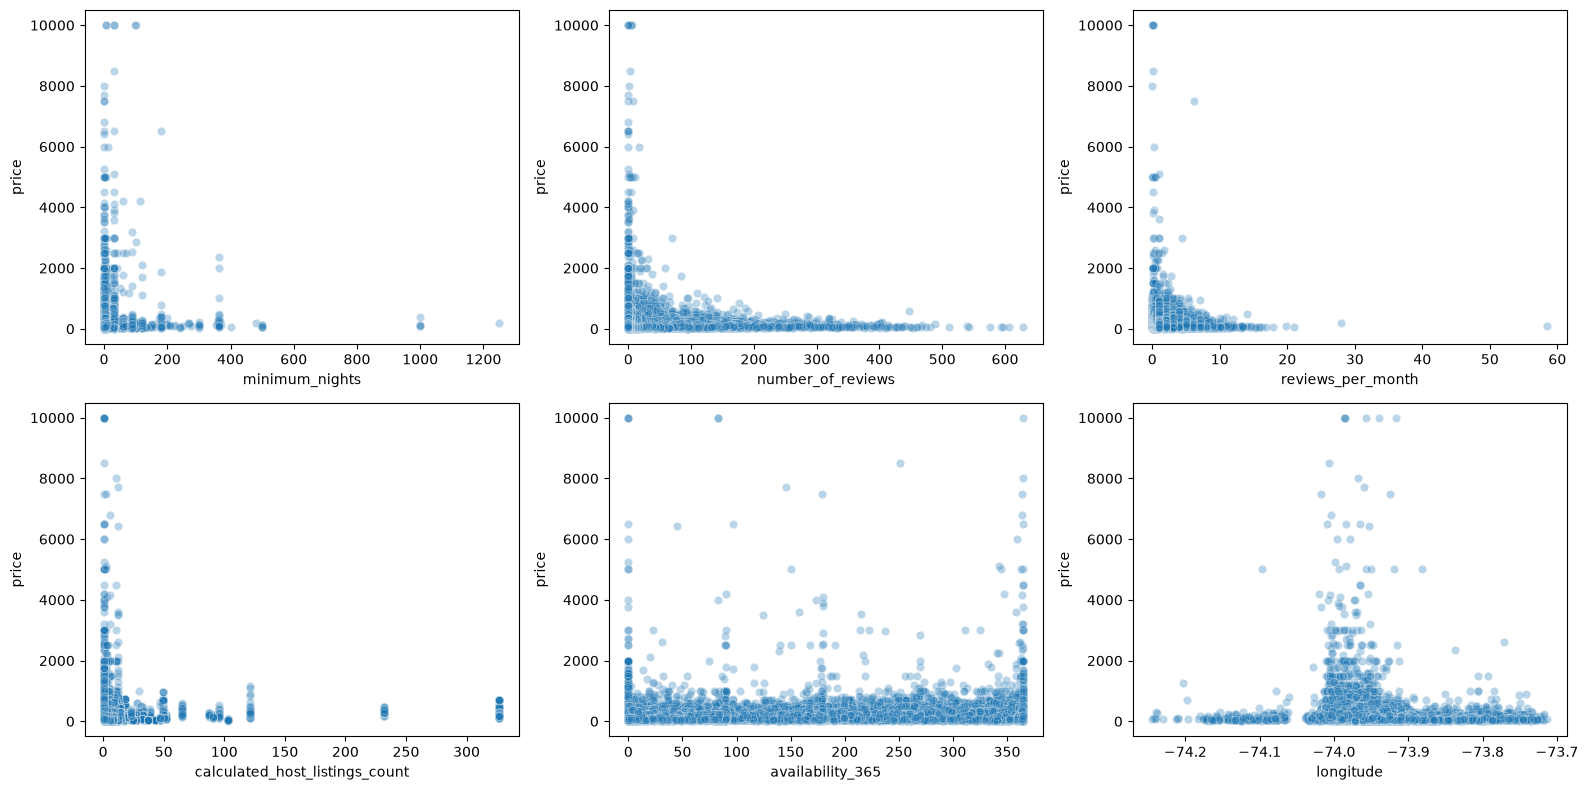

In [85]:
#numerica - numerica: relacion de cada variable con el precio
fig, axis = plt.subplots(2, 3, figsize = (16, 8))

variables = ["minimum_nights", "number_of_reviews", "reviews_per_month",
             "calculated_host_listings_count", "availability_365", "longitude"]

position = 0
for i in range(2):
    for j in range(3):
        sns.scatterplot(ax = axis[i, j], data = df, x = variables[position], y = "price", alpha = 0.3)
        position += 1

plt.tight_layout()
plt.show()

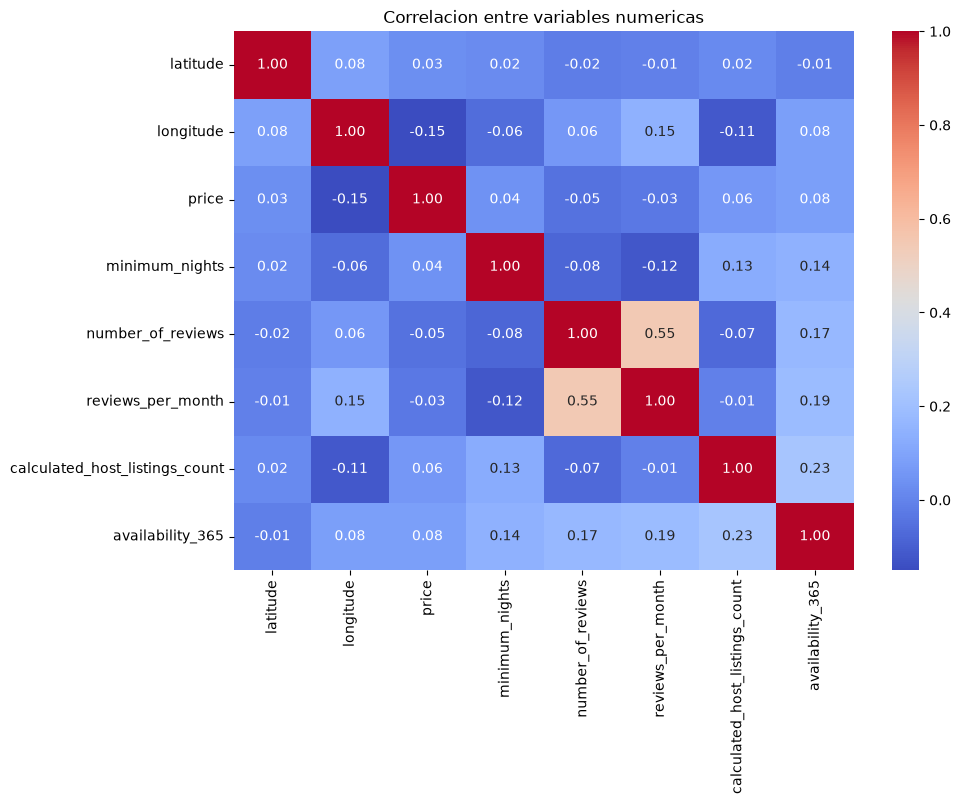

In [86]:
#matriz de correlacion de las variables numericas
plt.figure(figsize = (10, 7))
sns.heatmap(df.select_dtypes(include = np.number).corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlacion entre variables numericas")
plt.show()

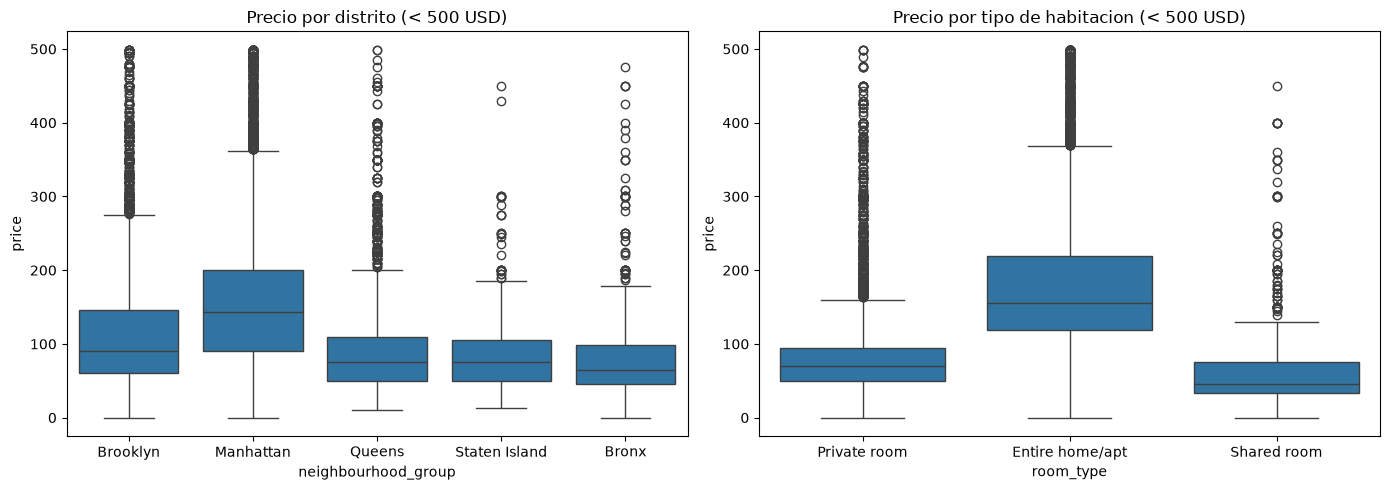

In [87]:
#categorica - numerica: precio segun distrito y tipo de habitacion
fig, axis = plt.subplots(1, 2, figsize = (14, 5))

sns.boxplot(ax = axis[0], data = df[df["price"] < 500], x = "neighbourhood_group", y = "price")
axis[0].set_title("Precio por distrito (< 500 USD)")

sns.boxplot(ax = axis[1], data = df[df["price"] < 500], x = "room_type", y = "price")
axis[1].set_title("Precio por tipo de habitacion (< 500 USD)")

plt.tight_layout()
plt.show()

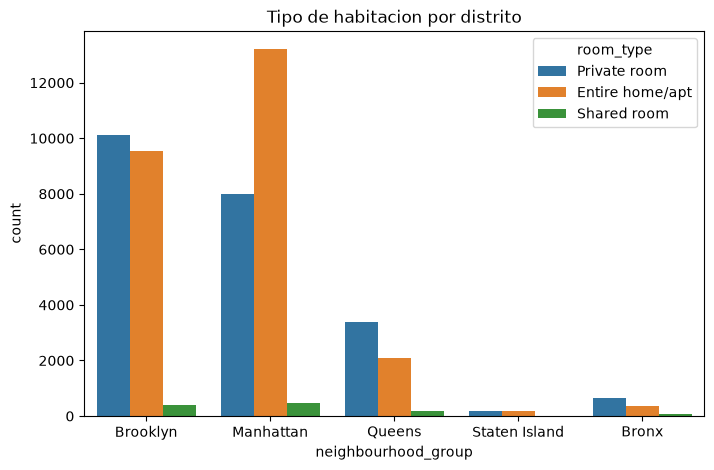

In [88]:
#categorica - categorica
plt.figure(figsize = (8, 5))
sns.countplot(data = df, x = "neighbourhood_group", hue = "room_type")
plt.title("Tipo de habitacion por distrito")
plt.show()

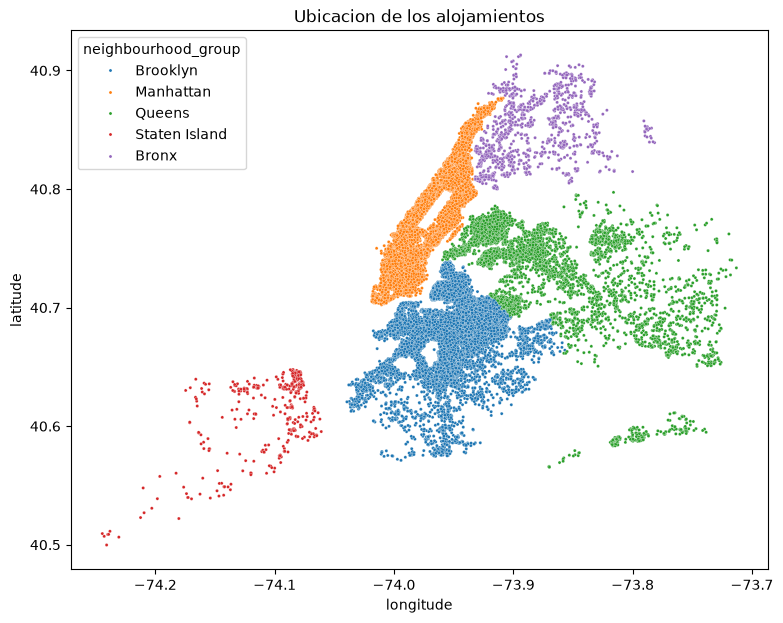

In [89]:
#mapa de los alojamientos coloreado por distrito
plt.figure(figsize = (9, 7))
sns.scatterplot(data = df, x = "longitude", y = "latitude", hue = "neighbourhood_group", s = 5)
plt.title("Ubicacion de los alojamientos")
plt.show()

In [90]:
#convirtiendo las categoricas a numeros para poder incluirlas en el analisis
df["neighbourhood_group_n"] = pd.factorize(df["neighbourhood_group"])[0]
df["neighbourhood_n"] = pd.factorize(df["neighbourhood"])[0]
df["room_type_n"] = pd.factorize(df["room_type"])[0]

#ya no necesitamos las columnas de texto
df = df.drop(["neighbourhood_group", "neighbourhood", "room_type"], axis = 1)

df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
0,40.64749,-73.97237,149,1,9,0.21,6,365,0,0,0
1,40.75362,-73.98377,225,1,45,0.38,2,355,1,1,1
2,40.80902,-73.94190,150,3,0,NaN,1,365,1,2,0
3,40.68514,-73.95976,89,1,270,4.64,1,194,0,3,1
4,40.79851,-73.94399,80,10,9,0.10,1,0,1,4,1


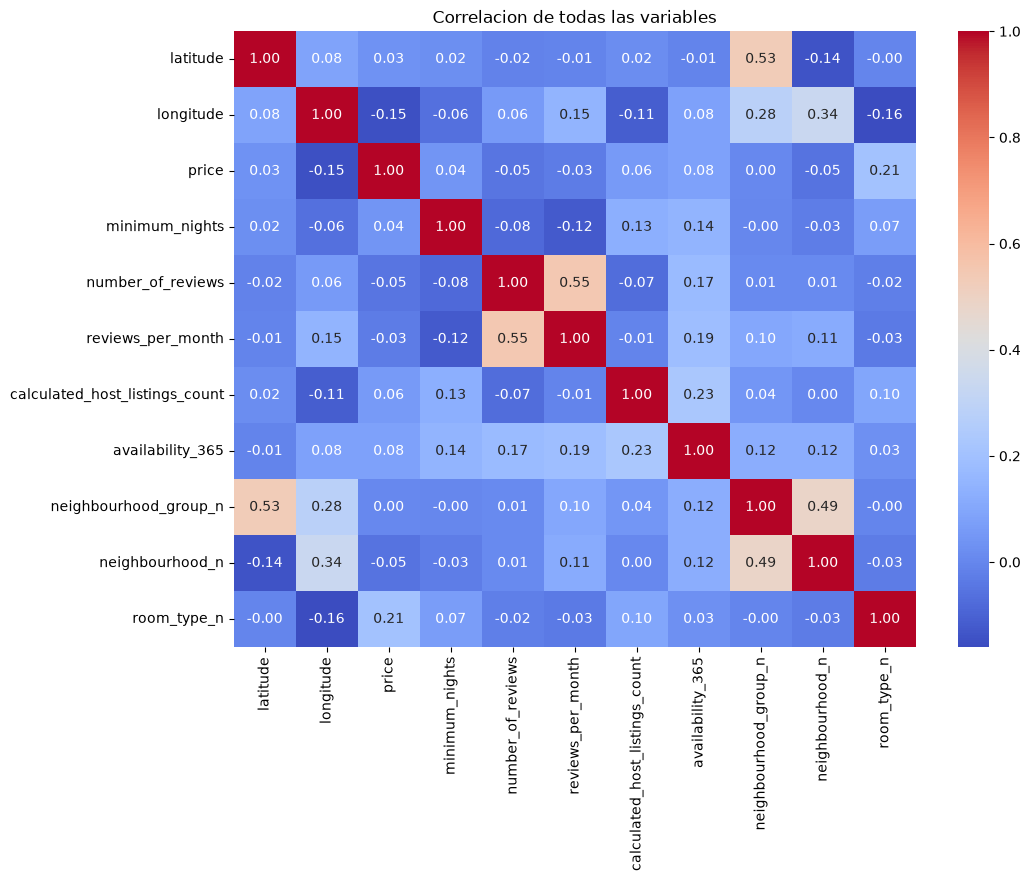

In [91]:
#correlacion completa, ya con las categoricas codificadas
plt.figure(figsize = (11, 8))
sns.heatmap(df.corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlacion de todas las variables")
plt.show()


- La variable mas relacionada con el precio es `room_type_n`, con una correlacion de **+0.21**.
  Es positiva porque `factorize` asigno el codigo mas alto a `Entire home/apt`, que es el tipo
  de alojamiento mas caro.
- `longitude` tiene **-0.15**: a medida que nos movemos hacia el este (Queens, Brooklyn profundo)
  el precio baja. Confirma que la **ubicacion** pesa.
- Ninguna correlacion supera 0.21 en valor absoluto. **Ninguna variable explica el precio por si
  sola**, hara falta un modelo que combine varias.
- `number_of_reviews` y `reviews_per_month` estan muy correlacionadas entre si (son redundantes)
  y su relacion con el precio es casi nula (-0.05).
- `neighbourhood_group_n`: su correlacion es **+0.003**, practicamente cero. Esto NO
  significa que el distrito no importe, sino que `factorize` le puso codigos arbitrarios
  (Brooklyn = 0, Manhattan = 1, Queens = 2...) y la correlacion de Pearson necesita un orden real.
  El boxplot de arriba demuestra que el distrito **si** influye. 

### Ingenieria de Caracteristicas ###

In [92]:
#Valores atipicos
#el nulo de reviews_per_month significa "cero resenas"
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(df.isnull().sum())

latitude                          0
longitude                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_n             0
neighbourhood_n                   0
room_type_n                       0
dtype: int64


In [93]:
#eliminamos los precios en 0, que son errores de carga, no existe un alquiler gratis
print("Alojamientos con precio 0:", len(df[df["price"] == 0]))

df = df[df["price"] > 0]
print("Filas restantes:", df.shape[0])

Alojamientos con precio 0: 11
Filas restantes: 48884


In [94]:
#rango intercuartilico (IQR) para calcular los limites de price y minimum_nights
estadisticas = df["price"].describe()
iqr = estadisticas["75%"] - estadisticas["25%"]
price_max_limit = estadisticas["75%"] + 1.5 * iqr
price_min_limit = estadisticas["25%"] - 1.5 * iqr

print("Limite superior precio:", price_max_limit)
print("Limite inferior precio:", price_min_limit)

Limite superior precio: 334.0
Limite inferior precio: -90.0


In [95]:
estadisticas = df["minimum_nights"].describe()
iqr = estadisticas["75%"] - estadisticas["25%"]
nights_top_limit = estadisticas["75%"] + 1.5 * iqr

print("Limite superior minimum_nights:", nights_top_limit)

Limite superior minimum_nights: 11.0


In [96]:
#Guardamos el tamaño antes y despues para saber cuanto perdemos
raws_before = df.shape[0]

df = df[df["price"] <= price_max_limit]
df = df[df["minimum_nights"] <= nights_top_limit]

print("Filas antes:", raws_before)
print("Filas despues:", df.shape[0])
print("Porcentaje eliminado:", round((raws_before - df.shape[0]) / raws_before * 100, 2), "%")

Filas antes: 48884
Filas despues: 39729
Porcentaje eliminado: 18.73 %


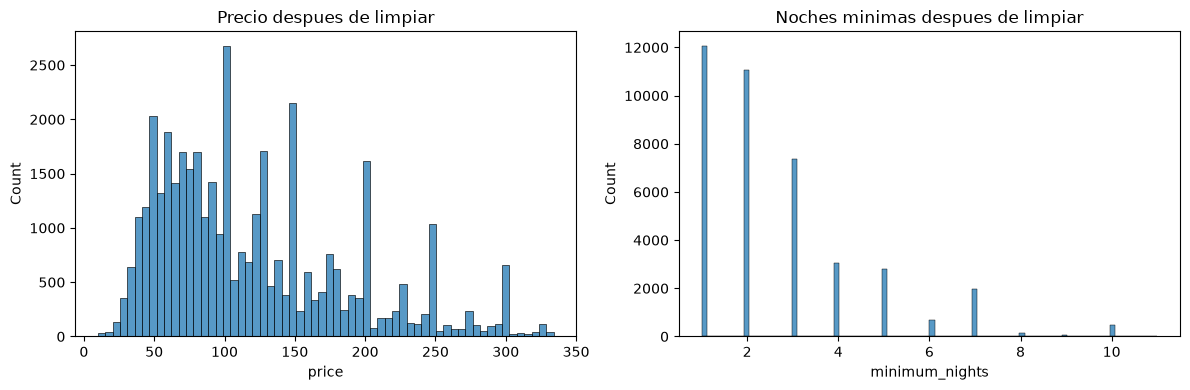

In [97]:
fig, axis = plt.subplots(1, 2, figsize = (12, 4))

sns.histplot(ax = axis[0], data = df, x = "price")
axis[0].set_title("Precio despues de limpiar")

sns.histplot(ax = axis[1], data = df, x = "minimum_nights")
axis[1].set_title("Noches minimas despues de limpiar")

plt.tight_layout()
plt.show()

In [98]:
#Division en train y test
from sklearn.model_selection import train_test_split

X = df.drop("price", axis = 1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (31783, 10)
X_test: (7946, 10)


Escalado

In [99]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#El scaler se ajusta SOLO con train, y luego se aplica a los dos conjuntos
scaler.fit(X_train)

X_train_esc = scaler.transform(X_train)
X_test_esc = scaler.transform(X_test)

#Los volvemos a DataFrame para no perder los nombres de las columnas
X_train_esc = pd.DataFrame(X_train_esc, index = X_train.index, columns = X_train.columns)
X_test_esc = pd.DataFrame(X_test_esc, index = X_test.index, columns = X_test.columns)

X_train_esc.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
24660,0.240303,0.837326,0.0,0.044515,0.021026,0.006135,0.687671,0.50,0.481818,0.0
18398,0.405498,0.579211,0.2,0.087440,0.026667,0.006135,0.134247,0.00,0.068182,0.0
8624,0.499214,0.430386,0.0,0.003180,0.000855,0.003067,0.000000,0.25,0.195455,0.0
3163,0.547777,0.457276,0.0,0.000000,0.000000,0.000000,0.000000,0.25,0.122727,0.5
35216,0.524258,0.540447,0.2,0.001590,0.002735,0.000000,0.005479,0.00,0.054545,0.5


### Seleccion de Caracteristicas ###

Nos quedamos solo con las variables que mas informacion aportan sobre el precio.
Como el target es continuo usamos `f_regression`

In [100]:
from sklearn.feature_selection import SelectKBest, f_regression

modelo_seleccion = SelectKBest(f_regression, k = 6)
modelo_seleccion.fit(X_train_esc, y_train)

columnas_elegidas = modelo_seleccion.get_support()

X_train_sel = pd.DataFrame(modelo_seleccion.transform(X_train_esc),
                           index = X_train_esc.index,
                           columns = X_train_esc.columns[columnas_elegidas])

X_test_sel = pd.DataFrame(modelo_seleccion.transform(X_test_esc),
                          index = X_test_esc.index,
                          columns = X_test_esc.columns[columnas_elegidas])

print("Variables seleccionadas:", list(X_train_sel.columns))
X_train_sel.head()

Variables seleccionadas: ['latitude', 'longitude', 'minimum_nights', 'calculated_host_listings_count', 'neighbourhood_n', 'room_type_n']


,latitude,longitude,minimum_nights,calculated_host_listings_count,neighbourhood_n,room_type_n
24660,0.240303,0.837326,0.0,0.006135,0.481818,0.0
18398,0.405498,0.579211,0.2,0.006135,0.068182,0.0
8624,0.499214,0.430386,0.0,0.003067,0.195455,0.0
3163,0.547777,0.457276,0.0,0.000000,0.122727,0.5
35216,0.524258,0.540447,0.2,0.000000,0.054545,0.5


In [101]:
#puntuacion de cada variable para justificar la seleccion
puntuaciones = pd.DataFrame()
puntuaciones["variable"] = X_train_esc.columns
puntuaciones["score"] = modelo_seleccion.scores_
puntuaciones = puntuaciones.sort_values("score", ascending = False)

puntuaciones

,variable,score
9,room_type_n,9564.223178
1,longitude,2952.340325
8,neighbourhood_n,711.697002
5,calculated_host_listings_count,264.907554
2,minimum_nights,117.036856
0,latitude,81.191472
4,reviews_per_month,63.797450
7,neighbourhood_group_n,34.847442
6,availability_365,31.505816
3,number_of_reviews,18.461064


In [103]:
#Guardamos los conjuntos procesados
X_train_sel.to_csv("/workspaces/machine-learning-python-template/data/processed/X_train.csv", index = False)
X_test_sel.to_csv("/workspaces/machine-learning-python-template/data/processed/X_test.csv", index = False)
y_train.to_csv("/workspaces/machine-learning-python-template/data/processed/y_train.csv", index = False)
y_test.to_csv("/workspaces/machine-learning-python-template/data/processed/y_test.csv", index = False)

print("Datos procesados guardados en ./data/processed/")

Datos procesados guardados en ./data/processed/


- El dataset partia de **48.895 anuncios y 16 columnas**, sin duplicados. Tras eliminar
  identificadores, texto libre y valores atipicos quedaron **39.729 registros y 10 variables
  predictoras** (31.783 en train y 7.946 en test).
- Los nulos se concentraban en `reviews_per_month` (10.052 registros) y **no eran datos
  perdidos**: los 10.052 corresponden exactamente a alojamientos con 0 reseñas, asi que se
  imputaron con 0. Tambien se eliminaron 11 anuncios con precio 0, que son errores de carga.
- El precio depende sobre todo del **tipo de alojamiento** y de la **ubicacion** (longitud,
  latitud y barrio). Manhattan es el distrito mas caro y los apartamentos completos cuestan
  claramente mas que las habitaciones privadas o compartidas.
- **Ninguna variable explica el precio por si sola** (la correlacion mas alta es 0.21). Un
  modelo lineal simple tendra un rendimiento limitado; probablemente convenga un modelo de
  arbol o ensemble.
- Las variables de resenas y la disponibilidad anual aportan muy poca informacion sobre el
  precio y quedaron fuera de la seleccion final.
- **Limitacion a mencionar:** `neighbourhood` se codifico con `factorize`, que asigna numeros
  arbitrarios a 221 barrios e introduce un orden que no existe. Una mejora seria usar
  *target encoding* o agrupar los barrios menos frecuentes.